<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionales2026/blob/main/Semana5/CuadraturaGaussiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
import sympy as sym

In [2]:
f = lambda x: np.cos(x)**2

In [30]:
def GetNewtonMethod(f,df,xn,itmax = 1000, precision=1e-5):

    error = 1.
    it = 0

    while error >= precision and it < itmax:

      dfx = df(xn)

      # Evitar división por cero
      if np.abs(dfx) < 1e-16:
            print("Derivada cercana a cero. Método falla.")
            return False

      xn1 = xn - f(xn)/df(xn)
      error = np.abs( xn1-xn )

      xn  = xn1
      it += 1


    if it == itmax:
        return False
    else:
        return xn

In [44]:


def GetNewtonMethod(f,df,xn,itmax = 1000, precision=1e-14):

    error = 1.
    it = 0

    while error >= precision and it < itmax:

      dfx = df(xn)

      # Evitar división por cero
      if np.abs(dfx) < 1e-16:
            print("Derivada cercana a cero. Método falla.")
            return False

      xn1 = xn - f(xn)/df(xn)
      error = np.abs( xn1-xn )

      xn  = xn1
      it += 1


    if it == itmax:
        return False
    else:
        return xn

def GetAllRoots(f, df, x, tolerancia_decimales=8, tol_unicidad=1e-6):

    Roots = []

    for x0 in x:

        root = GetNewtonMethod(f, df, x0)

        if root is not False:

            # Redondeamos
            croot = np.round(root, tolerancia_decimales)

            # Verificamos que no esté ya (con tolerancia)
            if not any(np.isclose(croot, r, atol=tol_unicidad) for r in Roots):
                Roots.append(croot)

    Roots = np.array(Roots)
    Roots.sort()

    return Roots

In [45]:
x = sym.Symbol('x',Real=True)
F = x**3 - x**4 - 2*x**2 + 2*x + 1
F

-x**4 + x**3 - 2*x**2 + 2*x + 1

In [46]:
DF = sym.diff(F,x)
DF

-4*x**3 + 3*x**2 - 4*x + 2

In [47]:
# Funcion en numpy
Fn = sym.lambdify([x],F,'numpy')
DFn = sym.lambdify([x],DF,'numpy')

In [50]:
xi = np.linspace(-1.,1,100,dtype=np.longdouble)
roots = GetAllRoots(Fn,DFn,xi)
roots

array([-0.34926802,  1.23106309], dtype=float128)

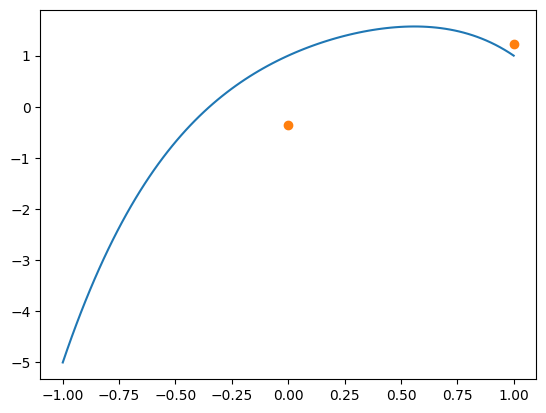

In [51]:
plt.plot(xi,Fn(xi))
plt.plot(roots,'o')